The notebook will build:

Strategic brand recommendations
Growth opportunities
Investment priorities
Defend / Invest / Monitor / Deprioritize recommendations
New-product opportunities
Portfolio optimization
Manufacturer recommendations
Therapeutic-class opportunities
Channel recommendations
Executive recommendation table
Final recommendation dashboard
Exportable outputs

In [5]:
# ============================================================
# PHARMALENS AI
# NOTEBOOK 06 — RECOMMENDATION INTELLIGENCE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("PharmaLens AI — Recommendation Intelligence")
print("Notebook 06")

PharmaLens AI — Recommendation Intelligence
Notebook 06


In [8]:
df=  pd.read_excel ("IMS (2021-2025).xlsx")

In [1]:
#from src.data_pipeline import load_master_data



In [3]:
#df = load_master_data()

Raw dataset loaded successfully!
Rows: 909,922
Columns: 13


ValueError: Missing columns: ['Distribution Channel', 'Therapeutic Class', 'Manufacturer', 'Brand Name', 'Pack Size', 'Product Launch', 'Drug Strength', 'Selling Price', 'Market Category', 'Month', 'Year', 'Sales Units', 'Sales Value']

In [9]:
df = df.rename(columns={
    "Sector": "Distribution Channel",
    "ATC4": "Therapeutic Class",
    "Corporation": "Manufacturer",
    "Product": "Brand Name",
    "Pack": "Pack Size",
    "Launch Date": "Product Launch",
    "Strength": "Drug Strength",
    "Retail Price": "Selling Price",
    "NFC3": "Market Category",
    "Period": "Month",
    "Calendar Year": "Year",
    "Units": "Sales Units",
    "LC Value": "Sales Value"
})

In [10]:
# ============================================================
# 1. VERIFY DATASET
# ============================================================

# The main dataset should already be loaded as df
# If df exists, continue directly.

if "df" not in globals():
    raise NameError(
        "DataFrame 'df' was not found. "
        "Please run the data-loading cell before Notebook 06."
    )

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (909922, 13)

Columns:
['Distribution Channel', 'Therapeutic Class', 'Manufacturer', 'Brand Name', 'Pack Size', 'Product Launch', 'Drug Strength', 'Selling Price', 'Market Category', 'Month', 'Year', 'Sales Units', 'Sales Value']


,Distribution Channel,Therapeutic Class,Manufacturer,Brand Name,Pack Size,Product Launch,Drug Strength,Selling Price,Market Category,Month,Year,Sales Units,Sales Value
0,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-01-01,2021,124790.0,1871850.0
1,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-02-01,2021,112962.0,1694430.0
2,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-03-01,2021,108014.0,1620210.0
3,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-04-01,2021,88090.0,1321350.0
4,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,MOUTH WASH 100ML,1990/04,000,49.9,KGA ORAL TOPICAL LIQUIDS,2021-05-01,2021,76111.0,1141665.0


In [11]:
# ============================================================
# 2. DATA TYPE STANDARDIZATION
# ============================================================

# Convert date columns
df["Product Launch"] = pd.to_datetime(
    df["Product Launch"],
    errors="coerce"
)

df["Month"] = pd.to_datetime(
    df["Month"],
    errors="coerce"
)

# Numeric columns
numeric_columns = [
    "Pack Size",
    "Drug Strength",
    "Selling Price",
    "Year",
    "Sales Units",
    "Sales Value"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Clean categorical columns
categorical_columns = [
    "Distribution Channel",
    "Therapeutic Class",
    "Manufacturer",
    "Brand Name",
    "Market Category"
]

for col in categorical_columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .replace("nan", np.nan)
    )

print("Data types standardized.")

Data types standardized.


In [12]:
# ============================================================
# 3. COLUMN VALIDATION
# ============================================================

required_columns = [
    "Distribution Channel",
    "Therapeutic Class",
    "Manufacturer",
    "Brand Name",
    "Pack Size",
    "Product Launch",
    "Drug Strength",
    "Selling Price",
    "Market Category",
    "Month",
    "Year",
    "Sales Units",
    "Sales Value"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required columns are available.")

All required columns are available.


In [13]:
# ============================================================
# 4. CREATE RECOMMENDATION BASE
# ============================================================

recommendation_df = df.copy()

# Remove rows without essential commercial information
recommendation_df = recommendation_df.dropna(
    subset=[
        "Brand Name",
        "Manufacturer",
        "Sales Value",
        "Sales Units"
    ]
)

print("Recommendation dataset shape:")
print(recommendation_df.shape)

recommendation_df.head()

Recommendation dataset shape:
(909922, 13)


,Distribution Channel,Therapeutic Class,Manufacturer,Brand Name,Pack Size,Product Launch,Drug Strength,Selling Price,Market Category,Month,Year,Sales Units,Sales Value
0,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,NaN,1990-04-01,0.0,49.9,KGA ORAL TOPICAL LIQUIDS,2021-01-01,2021,124790.0,1871850.0
1,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,NaN,1990-04-01,0.0,49.9,KGA ORAL TOPICAL LIQUIDS,2021-02-01,2021,112962.0,1694430.0
2,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,NaN,1990-04-01,0.0,49.9,KGA ORAL TOPICAL LIQUIDS,2021-03-01,2021,108014.0,1620210.0
3,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,NaN,1990-04-01,0.0,49.9,KGA ORAL TOPICAL LIQUIDS,2021-04-01,2021,88090.0,1321350.0
4,PHARMACIES,A01A0 STOMATOLOGICALS,ADCO*,HEXITOL,NaN,1990-04-01,0.0,49.9,KGA ORAL TOPICAL LIQUIDS,2021-05-01,2021,76111.0,1141665.0


In [14]:
# ============================================================
# 5. BRAND-LEVEL COMMERCIAL INTELLIGENCE
# ============================================================

brand_sales = (
    recommendation_df
    .groupby("Brand Name")
    .agg(
        Total_Sales_Value=("Sales Value", "sum"),
        Total_Sales_Units=("Sales Units", "sum"),
        Average_Price=("Selling Price", "mean"),
        Manufacturer=("Manufacturer", "first"),
        Therapeutic_Class=("Therapeutic Class", "first"),
        Market_Category=("Market Category", "first"),
        Product_Launch=("Product Launch", "min")
    )
    .reset_index()
)

brand_sales["Market_Share"] = (
    brand_sales["Total_Sales_Value"]
    / brand_sales["Total_Sales_Value"].sum()
)

brand_sales = brand_sales.sort_values(
    "Total_Sales_Value",
    ascending=False
)

brand_sales.head(20)

,Brand Name,Total_Sales_Value,Total_Sales_Units,Average_Price,Manufacturer,Therapeutic_Class,Market_Category,Product_Launch,Market_Share
9941,ZURCAL,7.804095e+09,9.966563e+07,113.057692,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,2014-05-01,0.008839
725,AUGMENTIN,6.813283e+09,5.642937e+07,134.842205,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,DGJ ORL L ORD DRY SUSP/SYR/DROPS,1996-02-01,0.007717
2091,CONTROLOC,6.360948e+09,5.248516e+07,144.662953,ACINO*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,2004-10-01,0.007205
6857,PANADOL,6.048820e+09,1.478063e+08,63.898594,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,ABC ORAL S ORD FILM-COATED TABS,2009-08-01,0.006851
1902,CLEXANE,5.555901e+09,2.716603e+07,332.242718,SANOFI,B01B2 FRACTIONATED HEPARINS,FNE P.ORD SC P/FILLED SYRNGS,1996-04-01,0.006293
3692,GABIMASH,5.308934e+09,3.802812e+07,147.752830,BIOMED PHARMA.*,N02D0 GABAPENTINOID PRODUCTS,AAA ORAL S ORD TABLETS,2012-02-01,0.006013
1286,BRUFEN,5.189706e+09,1.234969e+08,69.456647,ABBOTT*,M01A1 ANTIRHEUMATICS NON-S PLN,BBC ORAL S RET FILM-COATED TABS,1985-12-01,0.005878
4225,HIBIOTIC,5.093675e+09,5.724930e+07,106.724000,AMOUN PHARM.CO.*,J01C1 BROAD SPECT PENICILL ORAL,ABC ORAL S ORD FILM-COATED TABS,2000-02-01,0.005769
2094,CONVENTIN,4.798667e+09,5.190512e+07,124.571429,EVA PHARMA*,N02D0 GABAPENTINOID PRODUCTS,ACA ORAL S ORD CAPSULES,2010-09-01,0.005435
316,ALPHINTERN,4.095527e+09,7.132634e+07,87.000000,AMOUN PHARM.CO.*,V03H0 ANTI-INFLAMMATORY ENZYME,ABA ORAL S ORD COATED TABLETS,2012-06-01,0.004639


In [15]:
# ============================================================
# 6. BRAND GROWTH ANALYSIS
# ============================================================

monthly_brand = (
    recommendation_df
    .groupby(
        ["Brand Name", "Month"],
        as_index=False
    )["Sales Value"]
    .sum()
)

monthly_brand = monthly_brand.sort_values(
    ["Brand Name", "Month"]
)

monthly_brand["Previous_Sales"] = (
    monthly_brand
    .groupby("Brand Name")["Sales Value"]
    .shift(1)
)

monthly_brand["Growth_Rate"] = np.where(
    monthly_brand["Previous_Sales"] > 0,
    (
        monthly_brand["Sales Value"]
        - monthly_brand["Previous_Sales"]
    )
    / monthly_brand["Previous_Sales"],
    np.nan
)

brand_growth = (
    monthly_brand
    .groupby("Brand Name")
    .agg(
        Average_Growth=("Growth_Rate", "mean"),
        Latest_Growth=("Growth_Rate", "last"),
        Growth_Volatility=("Growth_Rate", "std")
    )
    .reset_index()
)

brand_sales = brand_sales.merge(
    brand_growth,
    on="Brand Name",
    how="left"
)

brand_sales.head()

,Brand Name,Total_Sales_Value,Total_Sales_Units,Average_Price,Manufacturer,Therapeutic_Class,Market_Category,Product_Launch,Market_Share,Average_Growth,Latest_Growth,Growth_Volatility
0,ZURCAL,7.804095e+09,9.966563e+07,113.057692,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,2014-05-01,0.008839,0.144522,-0.029507,0.431554
1,AUGMENTIN,6.813283e+09,5.642937e+07,134.842205,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,DGJ ORL L ORD DRY SUSP/SYR/DROPS,1996-02-01,0.007717,0.162927,-0.429715,0.616679
2,CONTROLOC,6.360948e+09,5.248516e+07,144.662953,ACINO*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,2004-10-01,0.007205,0.066089,0.109528,0.328597
3,PANADOL,6.048820e+09,1.478063e+08,63.898594,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,ABC ORAL S ORD FILM-COATED TABS,2009-08-01,0.006851,0.132205,0.322500,0.525997
4,CLEXANE,5.555901e+09,2.716603e+07,332.242718,SANOFI,B01B2 FRACTIONATED HEPARINS,FNE P.ORD SC P/FILLED SYRNGS,1996-04-01,0.006293,0.060350,-0.041452,0.324268


In [16]:
# ============================================================
# 7. BRAND MOMENTUM
# ============================================================

brand_sales["Growth_Score"] = (
    brand_sales["Average_Growth"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

brand_sales["Growth_Score"] = (
    brand_sales["Growth_Score"]
    .clip(-1, 2)
)

# Recent momentum
brand_sales["Momentum_Score"] = (
    brand_sales["Latest_Growth"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .clip(-1, 2)
)

brand_sales[
    [
        "Brand Name",
        "Total_Sales_Value",
        "Market_Share",
        "Average_Growth",
        "Latest_Growth"
    ]
].head(20)

,Brand Name,Total_Sales_Value,Market_Share,Average_Growth,Latest_Growth
0,ZURCAL,7.804095e+09,0.008839,0.144522,-0.029507
1,AUGMENTIN,6.813283e+09,0.007717,0.162927,-0.429715
2,CONTROLOC,6.360948e+09,0.007205,0.066089,0.109528
3,PANADOL,6.048820e+09,0.006851,0.132205,0.322500
4,CLEXANE,5.555901e+09,0.006293,0.060350,-0.041452
5,GABIMASH,5.308934e+09,0.006013,0.159022,-0.851444
6,BRUFEN,5.189706e+09,0.005878,0.069674,-0.084353
7,HIBIOTIC,5.093675e+09,0.005769,0.410659,0.457778
8,CONVENTIN,4.798667e+09,0.005435,0.219972,1.225038
9,ALPHINTERN,4.095527e+09,0.004639,0.309664,-0.040352


In [17]:
# ============================================================
# 8. NORMALIZE COMMERCIAL FEATURES
# ============================================================

scaler = MinMaxScaler()

features_to_scale = [
    "Total_Sales_Value",
    "Total_Sales_Units",
    "Market_Share"
]

for feature in features_to_scale:

    new_col = feature + "_Score"

    brand_sales[new_col] = scaler.fit_transform(
        brand_sales[[feature]]
    ).flatten()

# Growth normalization
growth_scaler = MinMaxScaler()

brand_sales["Growth_Normalized"] = (
    growth_scaler.fit_transform(
        brand_sales[["Growth_Score"]]
    ).flatten()
)

brand_sales["Momentum_Normalized"] = (
    growth_scaler.fit_transform(
        brand_sales[["Momentum_Score"]]
    ).flatten()
)

brand_sales.head()

,Brand Name,Total_Sales_Value,Total_Sales_Units,Average_Price,Manufacturer,Therapeutic_Class,Market_Category,Product_Launch,Market_Share,Average_Growth,Latest_Growth,Growth_Volatility,Growth_Score,Momentum_Score,Total_Sales_Value_Score,Total_Sales_Units_Score,Market_Share_Score,Growth_Normalized,Momentum_Normalized
0,ZURCAL,7.804095e+09,9.966563e+07,113.057692,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,2014-05-01,0.008839,0.144522,-0.029507,0.431554,0.144522,-0.029507,1.000000,0.617050,1.000000,0.380010,0.323475
1,AUGMENTIN,6.813283e+09,5.642937e+07,134.842205,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,DGJ ORL L ORD DRY SUSP/SYR/DROPS,1996-02-01,0.007717,0.162927,-0.429715,0.616679,0.162927,-0.429715,0.873039,0.349366,0.873039,0.386160,0.190068
2,CONTROLOC,6.360948e+09,5.248516e+07,144.662953,ACINO*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,2004-10-01,0.007205,0.066089,0.109528,0.328597,0.066089,0.109528,0.815078,0.324946,0.815078,0.353803,0.369821
3,PANADOL,6.048820e+09,1.478063e+08,63.898594,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,ABC ORAL S ORD FILM-COATED TABS,2009-08-01,0.006851,0.132205,0.322500,0.525997,0.132205,0.322500,0.775083,0.915099,0.775083,0.375895,0.440815
4,CLEXANE,5.555901e+09,2.716603e+07,332.242718,SANOFI,B01B2 FRACTIONATED HEPARINS,FNE P.ORD SC P/FILLED SYRNGS,1996-04-01,0.006293,0.060350,-0.041452,0.324268,0.060350,-0.041452,0.711921,0.168190,0.711921,0.351885,0.319493


In [18]:
# ============================================================
# 9. COMMERCIAL OPPORTUNITY SCORE
# ============================================================

brand_sales["Commercial_Opportunity_Score"] = (
    0.30 * brand_sales["Total_Sales_Value_Score"]
    + 0.20 * brand_sales["Market_Share_Score"]
    + 0.25 * brand_sales["Growth_Normalized"]
    + 0.15 * brand_sales["Momentum_Normalized"]
    + 0.10 * brand_sales["Total_Sales_Units_Score"]
)

brand_sales["Commercial_Opportunity_Score"] = (
    brand_sales["Commercial_Opportunity_Score"] * 100
)

brand_sales[
    [
        "Brand Name",
        "Manufacturer",
        "Total_Sales_Value",
        "Market_Share",
        "Average_Growth",
        "Commercial_Opportunity_Score"
    ]
].sort_values(
    "Commercial_Opportunity_Score",
    ascending=False
).head(20)

,Brand Name,Manufacturer,Total_Sales_Value,Market_Share,Average_Growth,Commercial_Opportunity_Score
0,ZURCAL,AUG PHARMA*,7.804095e+09,0.008839,0.144522,70.522883
3,PANADOL,HALEON*,6.048820e+09,0.006851,0.132205,63.914717
1,AUGMENTIN,GLAXOSMITHKLINE*,6.813283e+09,0.007717,0.162927,59.650649
2,CONTROLOC,ACINO*,6.360948e+09,0.007205,0.066089,58.395759
8,CONVENTIN,EVA PHARMA*,4.798667e+09,0.005435,0.219972,55.213682
7,HIBIOTIC,AMOUN PHARM.CO.*,5.093675e+09,0.005769,0.410659,55.191115
6,BRUFEN,ABBOTT*,5.189706e+09,0.005878,0.069674,54.348728
130,DEXAMETHASONE,MUP/ACDIMA,1.383001e+09,0.001566,3.800153,50.919236
4,CLEXANE,SANOFI,5.555901e+09,0.006293,0.060350,50.867487
5,GABIMASH,BIOMED PHARMA.*,5.308934e+09,0.006013,0.159022,46.731848


In [19]:
# ============================================================
# 10. STRATEGIC RECOMMENDATION ENGINE
# ============================================================

def generate_recommendation(row):

    score = row["Commercial_Opportunity_Score"]
    growth = row["Average_Growth"]
    share = row["Market_Share"]

    # High-value + high-growth
    if score >= 75 and growth > 0.10:
        return "INVEST & ACCELERATE"

    # Strong established brands
    elif score >= 65 and share >= 0.01:
        return "DEFEND & INVEST"

    # Growing opportunities
    elif score >= 50 and growth > 0.05:
        return "GROWTH OPPORTUNITY"

    # Medium strategic importance
    elif score >= 35:
        return "MONITOR & OPTIMIZE"

    # Weak commercial performance
    else:
        return "DEPRIORITIZE"


brand_sales["Strategic_Recommendation"] = (
    brand_sales.apply(
        generate_recommendation,
        axis=1
    )
)

brand_sales[
    [
        "Brand Name",
        "Commercial_Opportunity_Score",
        "Strategic_Recommendation"
    ]
].head(30)

,Brand Name,Commercial_Opportunity_Score,Strategic_Recommendation
0,ZURCAL,70.522883,GROWTH OPPORTUNITY
1,AUGMENTIN,59.650649,GROWTH OPPORTUNITY
2,CONTROLOC,58.395759,GROWTH OPPORTUNITY
3,PANADOL,63.914717,GROWTH OPPORTUNITY
4,CLEXANE,50.867487,GROWTH OPPORTUNITY
5,GABIMASH,46.731848,MONITOR & OPTIMIZE
6,BRUFEN,54.348728,GROWTH OPPORTUNITY
7,HIBIOTIC,55.191115,GROWTH OPPORTUNITY
8,CONVENTIN,55.213682,GROWTH OPPORTUNITY
9,ALPHINTERN,46.333226,MONITOR & OPTIMIZE


In [20]:
# ============================================================
# 11. RECOMMENDATION PRIORITY
# ============================================================

priority_map = {
    "INVEST & ACCELERATE": 1,
    "DEFEND & INVEST": 2,
    "GROWTH OPPORTUNITY": 3,
    "MONITOR & OPTIMIZE": 4,
    "DEPRIORITIZE": 5
}

brand_sales["Priority"] = (
    brand_sales["Strategic_Recommendation"]
    .map(priority_map)
)

brand_recommendations = (
    brand_sales
    .sort_values(
        [
            "Priority",
            "Commercial_Opportunity_Score"
        ],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

brand_recommendations.head(50)

,Brand Name,Total_Sales_Value,Total_Sales_Units,Average_Price,Manufacturer,Therapeutic_Class,Market_Category,Product_Launch,Market_Share,Average_Growth,Latest_Growth,Growth_Volatility,Growth_Score,Momentum_Score,Total_Sales_Value_Score,Total_Sales_Units_Score,Market_Share_Score,Growth_Normalized,Momentum_Normalized,Commercial_Opportunity_Score,Strategic_Recommendation,Priority
0,ZURCAL,7.804095e+09,9.966563e+07,113.057692,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,2014-05-01,0.008839,0.144522,-0.029507,0.431554,0.144522,-0.029507,1.000000,0.617050,1.000000,0.380010,0.323475,70.522883,GROWTH OPPORTUNITY,3
1,PANADOL,6.048820e+09,1.478063e+08,63.898594,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,ABC ORAL S ORD FILM-COATED TABS,2009-08-01,0.006851,0.132205,0.322500,0.525997,0.132205,0.322500,0.775083,0.915099,0.775083,0.375895,0.440815,63.914717,GROWTH OPPORTUNITY,3
2,AUGMENTIN,6.813283e+09,5.642937e+07,134.842205,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,DGJ ORL L ORD DRY SUSP/SYR/DROPS,1996-02-01,0.007717,0.162927,-0.429715,0.616679,0.162927,-0.429715,0.873039,0.349366,0.873039,0.386160,0.190068,59.650649,GROWTH OPPORTUNITY,3
3,CONTROLOC,6.360948e+09,5.248516e+07,144.662953,ACINO*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,2004-10-01,0.007205,0.066089,0.109528,0.328597,0.066089,0.109528,0.815078,0.324946,0.815078,0.353803,0.369821,58.395759,GROWTH OPPORTUNITY,3
4,CONVENTIN,4.798667e+09,5.190512e+07,124.571429,EVA PHARMA*,N02D0 GABAPENTINOID PRODUCTS,ACA ORAL S ORD CAPSULES,2010-09-01,0.005435,0.219972,1.225038,0.798929,0.219972,1.225038,0.614891,0.321355,0.614891,0.405221,0.741671,55.213682,GROWTH OPPORTUNITY,3
5,HIBIOTIC,5.093675e+09,5.724930e+07,106.724000,AMOUN PHARM.CO.*,J01C1 BROAD SPECT PENICILL ORAL,ABC ORAL S ORD FILM-COATED TABS,2000-02-01,0.005769,0.410659,0.457778,1.601779,0.410659,0.457778,0.652693,0.354442,0.652693,0.468937,0.485908,55.191115,GROWTH OPPORTUNITY,3
6,BRUFEN,5.189706e+09,1.234969e+08,69.456647,ABBOTT*,M01A1 ANTIRHEUMATICS NON-S PLN,BBC ORAL S RET FILM-COATED TABS,1985-12-01,0.005878,0.069674,-0.084353,0.319752,0.069674,-0.084353,0.664998,0.764594,0.664998,0.355001,0.305192,54.348728,GROWTH OPPORTUNITY,3
7,DEXAMETHASONE,1.383001e+09,3.324874e+07,61.872727,MUP/ACDIMA,H02A1 INJ CORTICOSTEROIDS PLAIN,FMA PARENTERAL ORDINARY AMPOULES,2007-12-01,0.001566,3.800153,3.956651,19.612882,2.000000,2.000000,0.177215,0.205850,0.177215,1.000000,1.000000,50.919236,GROWTH OPPORTUNITY,3
8,CLEXANE,5.555901e+09,2.716603e+07,332.242718,SANOFI,B01B2 FRACTIONATED HEPARINS,FNE P.ORD SC P/FILLED SYRNGS,1996-04-01,0.006293,0.060350,-0.041452,0.324268,0.060350,-0.041452,0.711921,0.168190,0.711921,0.351885,0.319493,50.867487,GROWTH OPPORTUNITY,3
9,GABIMASH,5.308934e+09,3.802812e+07,147.752830,BIOMED PHARMA.*,N02D0 GABAPENTINOID PRODUCTS,AAA ORAL S ORD TABLETS,2012-02-01,0.006013,0.159022,-0.851444,0.618141,0.159022,-0.851444,0.680275,0.235440,0.680275,0.384855,0.049487,46.731848,MONITOR & OPTIMIZE,4


In [21]:
# ============================================================
# 12. INVESTMENT RECOMMENDATIONS
# ============================================================

investment_recommendations = (
    brand_recommendations[
        brand_recommendations[
            "Strategic_Recommendation"
        ].isin([
            "INVEST & ACCELERATE",
            "DEFEND & INVEST",
            "GROWTH OPPORTUNITY"
        ])
    ]
    .copy()
)

investment_recommendations = (
    investment_recommendations
    .sort_values(
        "Commercial_Opportunity_Score",
        ascending=False
    )
)

print(
    "Number of investment opportunities:",
    len(investment_recommendations)
)

investment_recommendations.head(30)

Number of investment opportunities: 9


,Brand Name,Total_Sales_Value,Total_Sales_Units,Average_Price,Manufacturer,Therapeutic_Class,Market_Category,Product_Launch,Market_Share,Average_Growth,Latest_Growth,Growth_Volatility,Growth_Score,Momentum_Score,Total_Sales_Value_Score,Total_Sales_Units_Score,Market_Share_Score,Growth_Normalized,Momentum_Normalized,Commercial_Opportunity_Score,Strategic_Recommendation,Priority
0,ZURCAL,7.804095e+09,9.966563e+07,113.057692,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,2014-05-01,0.008839,0.144522,-0.029507,0.431554,0.144522,-0.029507,1.000000,0.617050,1.000000,0.380010,0.323475,70.522883,GROWTH OPPORTUNITY,3
1,PANADOL,6.048820e+09,1.478063e+08,63.898594,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,ABC ORAL S ORD FILM-COATED TABS,2009-08-01,0.006851,0.132205,0.322500,0.525997,0.132205,0.322500,0.775083,0.915099,0.775083,0.375895,0.440815,63.914717,GROWTH OPPORTUNITY,3
2,AUGMENTIN,6.813283e+09,5.642937e+07,134.842205,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,DGJ ORL L ORD DRY SUSP/SYR/DROPS,1996-02-01,0.007717,0.162927,-0.429715,0.616679,0.162927,-0.429715,0.873039,0.349366,0.873039,0.386160,0.190068,59.650649,GROWTH OPPORTUNITY,3
3,CONTROLOC,6.360948e+09,5.248516e+07,144.662953,ACINO*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,2004-10-01,0.007205,0.066089,0.109528,0.328597,0.066089,0.109528,0.815078,0.324946,0.815078,0.353803,0.369821,58.395759,GROWTH OPPORTUNITY,3
4,CONVENTIN,4.798667e+09,5.190512e+07,124.571429,EVA PHARMA*,N02D0 GABAPENTINOID PRODUCTS,ACA ORAL S ORD CAPSULES,2010-09-01,0.005435,0.219972,1.225038,0.798929,0.219972,1.225038,0.614891,0.321355,0.614891,0.405221,0.741671,55.213682,GROWTH OPPORTUNITY,3
5,HIBIOTIC,5.093675e+09,5.724930e+07,106.724000,AMOUN PHARM.CO.*,J01C1 BROAD SPECT PENICILL ORAL,ABC ORAL S ORD FILM-COATED TABS,2000-02-01,0.005769,0.410659,0.457778,1.601779,0.410659,0.457778,0.652693,0.354442,0.652693,0.468937,0.485908,55.191115,GROWTH OPPORTUNITY,3
6,BRUFEN,5.189706e+09,1.234969e+08,69.456647,ABBOTT*,M01A1 ANTIRHEUMATICS NON-S PLN,BBC ORAL S RET FILM-COATED TABS,1985-12-01,0.005878,0.069674,-0.084353,0.319752,0.069674,-0.084353,0.664998,0.764594,0.664998,0.355001,0.305192,54.348728,GROWTH OPPORTUNITY,3
7,DEXAMETHASONE,1.383001e+09,3.324874e+07,61.872727,MUP/ACDIMA,H02A1 INJ CORTICOSTEROIDS PLAIN,FMA PARENTERAL ORDINARY AMPOULES,2007-12-01,0.001566,3.800153,3.956651,19.612882,2.000000,2.000000,0.177215,0.205850,0.177215,1.000000,1.000000,50.919236,GROWTH OPPORTUNITY,3
8,CLEXANE,5.555901e+09,2.716603e+07,332.242718,SANOFI,B01B2 FRACTIONATED HEPARINS,FNE P.ORD SC P/FILLED SYRNGS,1996-04-01,0.006293,0.060350,-0.041452,0.324268,0.060350,-0.041452,0.711921,0.168190,0.711921,0.351885,0.319493,50.867487,GROWTH OPPORTUNITY,3


In [22]:
# ============================================================
# 13. HIGH-GROWTH OPPORTUNITIES
# ============================================================

growth_opportunities = brand_recommendations[
    (
        brand_recommendations["Average_Growth"] > 0.10
    )
    &
    (
        brand_recommendations["Commercial_Opportunity_Score"] >= 40
    )
].copy()

growth_opportunities = (
    growth_opportunities
    .sort_values(
        "Average_Growth",
        ascending=False
    )
)

print(
    "High-growth brands:",
    len(growth_opportunities)
)

growth_opportunities.head(30)

High-growth brands: 454


,Brand Name,Total_Sales_Value,Total_Sales_Units,Average_Price,Manufacturer,Therapeutic_Class,Market_Category,Product_Launch,Market_Share,Average_Growth,Latest_Growth,Growth_Volatility,Growth_Score,Momentum_Score,Total_Sales_Value_Score,Total_Sales_Units_Score,Market_Share_Score,Growth_Normalized,Momentum_Normalized,Commercial_Opportunity_Score,Strategic_Recommendation,Priority
188,TRICHOGYL,2.060360e+06,103018.00,20.000000,NASR*,G01A1 SYSTEMIC TRICHOMONACIDES,FMC PARENT ORD I V AMPOULES,1999-03-01,2.333677e-06,20597.962727,102991.000000,46059.108056,2.0,2.0,0.000264,0.000638,0.000264,1.0,1.0,40.019578,MONITOR & OPTIMIZE,4
63,DOXYMYCIN,5.110149e+07,3062683.13,30.000000,NILE*,J01A0 TETRACYCLINES & COMBS,ACA ORAL S ORD CAPSULES,1992-01-01,5.788035e-05,14010.816240,722508.756098,99229.408277,2.0,2.0,0.006548,0.018962,0.006548,1.0,1.0,40.517019,MONITOR & OPTIMIZE,4
62,HI-CAL,5.643540e+07,2691865.93,50.000000,MUP/ACDIMA,A12A0 CALCIUM,DGM ORAL L ORD SYRUPS,1998-06-01,6.392183e-05,7855.090740,2.290068,60331.282509,2.0,2.0,0.007232,0.016666,0.007232,1.0,1.0,40.528234,MONITOR & OPTIMIZE,4
49,STIMU-MAX,9.853556e+07,4796899.00,39.807018,SEDICO/ACDIMA,G04E1 ERECT DYS PRD PDE5 INHIB,AAA ORAL S ORD TABLETS,2006-11-01,1.116068e-04,2925.657171,9.983040,22228.086101,2.0,2.0,0.012626,0.029699,0.012626,1.0,1.0,40.928292,MONITOR & OPTIMIZE,4
34,TRITOSPOT,1.873435e+08,8432844.46,51.419355,EVA PHARMA*,D11A0 OTHER DERMATOLOGICAL PREP,MTA TOPICAL EXTERNAL CREAMS,2003-11-01,2.121955e-04,1997.487779,111493.526316,14640.904336,2.0,2.0,0.024006,0.052209,0.024006,1.0,1.0,41.722384,MONITOR & OPTIMIZE,4
83,CETAFEN PLUS,4.163446e+07,804717.10,81.000000,QUEEN PH. GROUP*,N02B0 NON-NARCOTIC ANALGESICS,AAA ORAL S ORD TABLETS,2011-03-01,4.715747e-05,1846.066290,102525.000000,13575.884415,2.0,2.0,0.005335,0.004982,0.005335,1.0,1.0,40.316569,MONITOR & OPTIMIZE,4
146,PROTHIADEN,5.483968e+06,339018.57,15.908257,ABBOTT*,N06A9 ANTIDEPRESSANTS ALL OTH,ACA ORAL S ORD CAPSULES,2012-04-01,6.211443e-06,1539.399049,5.142857,8975.405280,2.0,2.0,0.000703,0.002099,0.000703,1.0,1.0,40.056124,MONITOR & OPTIMIZE,4
222,METFORMIN,6.788170e+05,64740.06,5.623077,ALEXANDRIA*,A10J1 BIGUANIDE A-DIABS PLAIN,ABC ORAL S ORD FILM-COATED TABS,1999-02-01,7.688653e-07,1427.074707,4.666667,7840.310968,2.0,2.0,0.000087,0.000401,0.000087,1.0,1.0,40.008357,MONITOR & OPTIMIZE,4
143,CILOZINC,8.683449e+06,62837.00,144.000000,MULTICARE*,A11G2 VITAMIN C COMBINATIONS,ACA ORAL S ORD CAPSULES,2021-11-01,9.835351e-06,1337.554878,101.102041,7593.352120,2.0,2.0,0.001113,0.000389,0.001113,1.0,1.0,40.059524,MONITOR & OPTIMIZE,4
48,CYRINOL,8.406841e+07,6302355.99,14.517241,AMOUN PHARM.CO.*,R05D2 ANTITUSSIVES COMB,DGM ORAL L ORD SYRUPS,1999-04-01,9.522049e-05,1191.748724,3.800000,8164.403298,2.0,2.0,0.010772,0.039019,0.010772,1.0,1.0,40.928809,MONITOR & OPTIMIZE,4


In [23]:
# ============================================================
# 14. NEW PRODUCT OPPORTUNITY ANALYSIS
# ============================================================

therapeutic_market = (
    recommendation_df
    .groupby("Therapeutic Class")
    .agg(
        Market_Value=("Sales Value", "sum"),
        Market_Units=("Sales Units", "sum"),
        Brand_Count=("Brand Name", "nunique"),
        Manufacturer_Count=("Manufacturer", "nunique")
    )
    .reset_index()
)

therapeutic_market["Market_Share"] = (
    therapeutic_market["Market_Value"]
    / therapeutic_market["Market_Value"].sum()
)

# Calculate therapeutic-class growth
monthly_therapy = (
    recommendation_df
    .groupby(
        ["Therapeutic Class", "Month"],
        as_index=False
    )["Sales Value"]
    .sum()
)

monthly_therapy = monthly_therapy.sort_values(
    ["Therapeutic Class", "Month"]
)

monthly_therapy["Previous_Value"] = (
    monthly_therapy
    .groupby("Therapeutic Class")["Sales Value"]
    .shift(1)
)

monthly_therapy["Growth"] = np.where(
    monthly_therapy["Previous_Value"] > 0,
    (
        monthly_therapy["Sales Value"]
        - monthly_therapy["Previous_Value"]
    )
    / monthly_therapy["Previous_Value"],
    np.nan
)

therapy_growth = (
    monthly_therapy
    .groupby("Therapeutic Class")
    .agg(
        Average_Growth=("Growth", "mean")
    )
    .reset_index()
)

therapeutic_opportunities = therapeutic_market.merge(
    therapy_growth,
    on="Therapeutic Class",
    how="left"
)

therapeutic_opportunities["Opportunity_Score"] = (
    therapeutic_opportunities["Market_Share"] * 50
    +
    therapeutic_opportunities["Average_Growth"]
    .fillna(0)
    .clip(-1, 2)
    * 50
)

therapeutic_opportunities = (
    therapeutic_opportunities
    .sort_values(
        "Opportunity_Score",
        ascending=False
    )
)

therapeutic_opportunities.head(30)

,Therapeutic Class,Market_Value,Market_Units,Brand_Count,Manufacturer_Count,Market_Share,Average_Growth,Opportunity_Score
294,J07E1 INFLUENZA VACCINES,1.198006e+09,4556104.01,2,2,0.001357,9139.155516,100.067846
475,S01P0 OCULAR ANTINEOVASC.PRODS,6.235957e+08,57179.00,4,3,0.000706,11.410254,100.035316
28,A05C0 CHOLAGOG-LIPOTROPIC-COMBS,6.167823e+08,5485938.38,2,2,0.000699,2.955097,100.034930
274,J05B6 CORONAVIRUS ANTIVIRALS,4.621750e+08,728097.96,22,13,0.000523,11.068530,100.026174
17,A03D0 ANTISPASM\ANALGESIC COMBS,3.062450e+08,6615196.75,4,3,0.000347,8.747555,100.017343
34,A06A7 OSMOTIC LAXATS W ELECTRO,1.823571e+08,883641.91,2,2,0.000207,1161.802364,100.010327
249,H04X0 OTHER HORMONES & SIMILAR,1.736179e+08,1086334.08,17,22,0.000197,28.669810,100.009832
197,G01A2 TOPICAL TRICHOMONACIDES,1.441219e+08,9249405.85,4,2,0.000163,36.038158,100.008162
287,J06J0 OTH SPECIFC IMMUNOGLOBULN,1.380921e+08,81584.00,2,2,0.000156,10.653654,100.007821
401,N06A3 MOOD STABILISERS,1.325175e+08,1342544.17,2,2,0.000150,2.489467,100.007505


In [24]:
# ============================================================
# 15. MANUFACTURER STRATEGIC OPPORTUNITIES
# ============================================================

manufacturer_intelligence = (
    recommendation_df
    .groupby("Manufacturer")
    .agg(
        Total_Sales=("Sales Value", "sum"),
        Total_Units=("Sales Units", "sum"),
        Brand_Count=("Brand Name", "nunique"),
        Therapeutic_Class_Count=(
            "Therapeutic Class",
            "nunique"
        ),
        Average_Price=("Selling Price", "mean")
    )
    .reset_index()
)

manufacturer_intelligence["Market_Share"] = (
    manufacturer_intelligence["Total_Sales"]
    / manufacturer_intelligence["Total_Sales"].sum()
)

manufacturer_intelligence = (
    manufacturer_intelligence
    .sort_values(
        "Total_Sales",
        ascending=False
    )
)

manufacturer_intelligence.head(30)

,Manufacturer,Total_Sales,Total_Units,Brand_Count,Therapeutic_Class_Count,Average_Price,Market_Share
991,PHARCO*,4.286563e+10,1.367007e+09,310,164,63.407992,0.048552
1157,SANOFI,3.950244e+10,6.511505e+08,97,78,1212.634740,0.044743
97,AMOUN PHARM.CO.*,3.176665e+10,8.093866e+08,127,109,96.240481,0.035981
901,NOVARTIS,2.979254e+10,3.468835e+08,84,49,3701.833361,0.033745
382,EIPICO/ACDIMA,2.639026e+10,1.042051e+09,186,112,45.205502,0.029891
498,GLAXOSMITHKLINE*,2.461002e+10,5.206891e+08,96,68,472.620601,0.027875
431,EVA PHARMA*,2.406643e+10,2.397848e+08,173,112,258.894466,0.027259
759,MARCYRL*,2.244227e+10,2.892759e+08,167,107,167.044150,0.025419
105,APEX PHARMA*,2.048389e+10,3.071037e+08,76,57,131.877634,0.023201
147,AUG PHARMA*,2.046888e+10,2.625579e+08,89,58,154.123300,0.023184


In [25]:
# ============================================================
# 16. DISTRIBUTION CHANNEL OPPORTUNITIES
# ============================================================

channel_intelligence = (
    recommendation_df
    .groupby("Distribution Channel")
    .agg(
        Total_Sales=("Sales Value", "sum"),
        Total_Units=("Sales Units", "sum"),
        Brand_Count=("Brand Name", "nunique"),
        Manufacturer_Count=("Manufacturer", "nunique")
    )
    .reset_index()
)

channel_intelligence["Market_Share"] = (
    channel_intelligence["Total_Sales"]
    / channel_intelligence["Total_Sales"].sum()
)

channel_intelligence["Average_Value_per_Unit"] = (
    channel_intelligence["Total_Sales"]
    / channel_intelligence["Total_Units"].replace(0, np.nan)
)

channel_intelligence = (
    channel_intelligence
    .sort_values(
        "Total_Sales",
        ascending=False
    )
)

channel_intelligence

,Distribution Channel,Total_Sales,Total_Units,Brand_Count,Manufacturer_Count,Market_Share,Average_Value_per_Unit
0,PHARMACIES,6.142002e+11,1.033845e+10,9916,1391,0.695677,59.409321
1,STORES,2.686812e+11,4.971962e+09,7810,951,0.304323,54.039278


In [36]:
# ============================================================
# 17. PORTFOLIO RECOMMENDATION — FINAL FIX
# ============================================================

# ------------------------------------------------------------
# Step 1 — Create a brand-level mapping from the original data
# ------------------------------------------------------------

brand_metadata = (
    df.groupby("Brand Name")
    .agg(
        Therapeutic_Class=("Therapeutic Class", "first"),
        Market_Category=("Market Category", "first")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Step 2 — Remove old versions if they already exist
# ------------------------------------------------------------

for col in ["Therapeutic Class", "Market Category",
            "Therapeutic_Class", "Market_Category"]:

    if col in brand_recommendations.columns:
        brand_recommendations = (
            brand_recommendations.drop(columns=[col])
        )

# ------------------------------------------------------------
# Step 3 — Merge the original metadata
# ------------------------------------------------------------

brand_recommendations = brand_recommendations.merge(
    brand_metadata,
    on="Brand Name",
    how="left"
)

# ------------------------------------------------------------
# Step 4 — Create Portfolio Action
# ------------------------------------------------------------

brand_recommendations["Portfolio_Action"] = (
    brand_recommendations[
        "Strategic_Recommendation"
    ].map({

        "INVEST & ACCELERATE":
            "Increase commercial investment and accelerate GTM",

        "DEFEND & INVEST":
            "Protect market share and strengthen competitive position",

        "GROWTH OPPORTUNITY":
            "Increase promotion and expand distribution",

        "MONITOR & OPTIMIZE":
            "Optimize resources and monitor market performance",

        "DEPRIORITIZE":
            "Reduce investment and reassess portfolio role"
    })
)

# ------------------------------------------------------------
# Step 5 — Create final portfolio recommendation table
# ------------------------------------------------------------

portfolio_recommendation = brand_recommendations[
    [
        "Brand Name",
        "Manufacturer",
        "Therapeutic_Class",
        "Market_Category",
        "Total_Sales_Value",
        "Market_Share",
        "Average_Growth",
        "Commercial_Opportunity_Score",
        "Strategic_Recommendation",
        "Portfolio_Action"
    ]
].copy()

# ------------------------------------------------------------
# Step 6 — Rename columns for final business output
# ------------------------------------------------------------

portfolio_recommendation = (
    portfolio_recommendation.rename(
        columns={
            "Therapeutic_Class": "Therapeutic Class",
            "Market_Category": "Market Category"
        }
    )
)

# ------------------------------------------------------------
# Step 7 — Display
# ------------------------------------------------------------

print("Portfolio recommendation created successfully.")

print(
    "Shape:",
    portfolio_recommendation.shape
)

portfolio_recommendation.head(30)

Portfolio recommendation created successfully.
Shape: (9958, 10)


,Brand Name,Manufacturer,Therapeutic Class,Market Category,Total_Sales_Value,Market_Share,Average_Growth,Commercial_Opportunity_Score,Strategic_Recommendation,Portfolio_Action
0,ZURCAL,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,7.804095e+09,0.008839,0.144522,70.522883,GROWTH OPPORTUNITY,Increase promotion and expand distribution
1,PANADOL,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,ABC ORAL S ORD FILM-COATED TABS,6.048820e+09,0.006851,0.132205,63.914717,GROWTH OPPORTUNITY,Increase promotion and expand distribution
2,AUGMENTIN,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,DGJ ORL L ORD DRY SUSP/SYR/DROPS,6.813283e+09,0.007717,0.162927,59.650649,GROWTH OPPORTUNITY,Increase promotion and expand distribution
3,CONTROLOC,ACINO*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,6.360948e+09,0.007205,0.066089,58.395759,GROWTH OPPORTUNITY,Increase promotion and expand distribution
4,CONVENTIN,EVA PHARMA*,N02D0 GABAPENTINOID PRODUCTS,ACA ORAL S ORD CAPSULES,4.798667e+09,0.005435,0.219972,55.213682,GROWTH OPPORTUNITY,Increase promotion and expand distribution
5,HIBIOTIC,AMOUN PHARM.CO.*,J01C1 BROAD SPECT PENICILL ORAL,ABC ORAL S ORD FILM-COATED TABS,5.093675e+09,0.005769,0.410659,55.191115,GROWTH OPPORTUNITY,Increase promotion and expand distribution
6,BRUFEN,ABBOTT*,M01A1 ANTIRHEUMATICS NON-S PLN,BBC ORAL S RET FILM-COATED TABS,5.189706e+09,0.005878,0.069674,54.348728,GROWTH OPPORTUNITY,Increase promotion and expand distribution
7,DEXAMETHASONE,MUP/ACDIMA,H02A1 INJ CORTICOSTEROIDS PLAIN,FMA PARENTERAL ORDINARY AMPOULES,1.383001e+09,0.001566,3.800153,50.919236,GROWTH OPPORTUNITY,Increase promotion and expand distribution
8,CLEXANE,SANOFI,B01B2 FRACTIONATED HEPARINS,FNE P.ORD SC P/FILLED SYRNGS,5.555901e+09,0.006293,0.060350,50.867487,GROWTH OPPORTUNITY,Increase promotion and expand distribution
9,GABIMASH,BIOMED PHARMA.*,N02D0 GABAPENTINOID PRODUCTS,AAA ORAL S ORD TABLETS,5.308934e+09,0.006013,0.159022,46.731848,MONITOR & OPTIMIZE,Optimize resources and monitor market performance


In [37]:
# ============================================================
# 18. RECOMMENDATION SUMMARY
# ============================================================

recommendation_summary = (
    brand_recommendations[
        "Strategic_Recommendation"
    ]
    .value_counts()
    .reset_index()
)

recommendation_summary.columns = [
    "Recommendation",
    "Brand_Count"
]

recommendation_summary["Percentage"] = (
    recommendation_summary["Brand_Count"]
    / recommendation_summary["Brand_Count"].sum()
    * 100
)

recommendation_summary

,Recommendation,Brand_Count,Percentage
0,DEPRIORITIZE,9255,92.940349
1,MONITOR & OPTIMIZE,694,6.969271
2,GROWTH OPPORTUNITY,9,0.090380


In [38]:
# ============================================================
# 19. STRATEGIC RECOMMENDATION MATRIX
# ============================================================

brand_recommendations["Growth_Category"] = np.select(
    [
        brand_recommendations["Average_Growth"] >= 0.15,
        brand_recommendations["Average_Growth"] >= 0.05,
        brand_recommendations["Average_Growth"] >= 0
    ],
    [
        "High Growth",
        "Moderate Growth",
        "Stable"
    ],
    default="Declining"
)

brand_recommendations["Market_Position"] = np.select(
    [
        brand_recommendations["Market_Share"] >= 0.01,
        brand_recommendations["Market_Share"] >= 0.002
    ],
    [
        "High Market Share",
        "Medium Market Share"
    ],
    default="Low Market Share"
)

recommendation_matrix = (
    brand_recommendations
    .groupby(
        [
            "Growth_Category",
            "Market_Position"
        ]
    )
    .agg(
        Brand_Count=("Brand Name", "nunique"),
        Total_Sales=("Total_Sales_Value", "sum"),
        Average_Opportunity_Score=(
            "Commercial_Opportunity_Score",
            "mean"
        )
    )
    .reset_index()
)

recommendation_matrix

,Growth_Category,Market_Position,Brand_Count,Total_Sales,Average_Opportunity_Score
0,Declining,Low Market Share,1214,1.876484e+09,10.748056
1,High Growth,Low Market Share,7048,4.746294e+11,23.837842
2,High Growth,Medium Market Share,42,1.137110e+11,37.335086
3,Moderate Growth,Low Market Share,1111,1.547121e+11,15.087679
4,Moderate Growth,Medium Market Share,37,1.097385e+11,35.833305
5,Stable,Low Market Share,502,1.949112e+10,13.374100
6,Stable,Medium Market Share,4,8.722947e+09,28.507198


In [44]:
# ============================================================
# 20. TOP 20 STRATEGIC RECOMMENDATIONS — FINAL FIX
# ============================================================

# Make sure therapeutic and market category information
# exists in brand_recommendations

if "Therapeutic_Class" not in brand_recommendations.columns:

    brand_metadata = (
        df.groupby("Brand Name")
        .agg(
            Therapeutic_Class=("Therapeutic Class", "first"),
            Market_Category=("Market Category", "first")
        )
        .reset_index()
    )

    brand_recommendations = brand_recommendations.merge(
        brand_metadata,
        on="Brand Name",
        how="left"
    )

# ------------------------------------------------------------
# Create Top 20 Recommendations
# ------------------------------------------------------------

top_20_recommendations = (
    brand_recommendations[
        [
            "Brand Name",
            "Manufacturer",
            "Therapeutic_Class",
            "Total_Sales_Value",
            "Market_Share",
            "Average_Growth",
            "Commercial_Opportunity_Score",
            "Strategic_Recommendation",
            "Portfolio_Action"
        ]
    ]
    .sort_values(
        "Commercial_Opportunity_Score",
        ascending=False
    )
    .head(20)
    .copy()
)

# ------------------------------------------------------------
# Rename for final business output
# ------------------------------------------------------------

top_20_recommendations = (
    top_20_recommendations.rename(
        columns={
            "Therapeutic_Class": "Therapeutic Class"
        }
    )
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("=" * 70)
print("TOP 20 STRATEGIC RECOMMENDATIONS")
print("=" * 70)

print(
    "Number of recommendations:",
    len(top_20_recommendations)
)

top_20_recommendations

TOP 20 STRATEGIC RECOMMENDATIONS
Number of recommendations: 20


,Brand Name,Manufacturer,Therapeutic Class,Total_Sales_Value,Market_Share,Average_Growth,Commercial_Opportunity_Score,Strategic_Recommendation,Portfolio_Action
0,ZURCAL,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,7.804095e+09,0.008839,0.144522,70.522883,GROWTH OPPORTUNITY,Increase promotion and expand distribution
1,PANADOL,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,6.048820e+09,0.006851,0.132205,63.914717,GROWTH OPPORTUNITY,Increase promotion and expand distribution
2,AUGMENTIN,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,6.813283e+09,0.007717,0.162927,59.650649,GROWTH OPPORTUNITY,Increase promotion and expand distribution
3,CONTROLOC,ACINO*,A02B2 PROTON PUMP INHIBITORS,6.360948e+09,0.007205,0.066089,58.395759,GROWTH OPPORTUNITY,Increase promotion and expand distribution
4,CONVENTIN,EVA PHARMA*,N02D0 GABAPENTINOID PRODUCTS,4.798667e+09,0.005435,0.219972,55.213682,GROWTH OPPORTUNITY,Increase promotion and expand distribution
5,HIBIOTIC,AMOUN PHARM.CO.*,J01C1 BROAD SPECT PENICILL ORAL,5.093675e+09,0.005769,0.410659,55.191115,GROWTH OPPORTUNITY,Increase promotion and expand distribution
6,BRUFEN,ABBOTT*,M01A1 ANTIRHEUMATICS NON-S PLN,5.189706e+09,0.005878,0.069674,54.348728,GROWTH OPPORTUNITY,Increase promotion and expand distribution
7,DEXAMETHASONE,MUP/ACDIMA,H02A1 INJ CORTICOSTEROIDS PLAIN,1.383001e+09,0.001566,3.800153,50.919236,GROWTH OPPORTUNITY,Increase promotion and expand distribution
8,CLEXANE,SANOFI,B01B2 FRACTIONATED HEPARINS,5.555901e+09,0.006293,0.060350,50.867487,GROWTH OPPORTUNITY,Increase promotion and expand distribution
9,GABIMASH,BIOMED PHARMA.*,N02D0 GABAPENTINOID PRODUCTS,5.308934e+09,0.006013,0.159022,46.731848,MONITOR & OPTIMIZE,Optimize resources and monitor market performance


In [45]:
# ============================================================
# CHECK BRAND RECOMMENDATIONS COLUMNS
# ============================================================

print(brand_recommendations.columns.tolist())

['Brand Name', 'Total_Sales_Value', 'Total_Sales_Units', 'Average_Price', 'Manufacturer', 'Product_Launch', 'Market_Share', 'Average_Growth', 'Latest_Growth', 'Growth_Volatility', 'Growth_Score', 'Momentum_Score', 'Total_Sales_Value_Score', 'Total_Sales_Units_Score', 'Market_Share_Score', 'Growth_Normalized', 'Momentum_Normalized', 'Commercial_Opportunity_Score', 'Strategic_Recommendation', 'Priority', 'Portfolio_Action', 'Growth_Category', 'Market_Position', 'Therapeutic_Class', 'Market_Category']


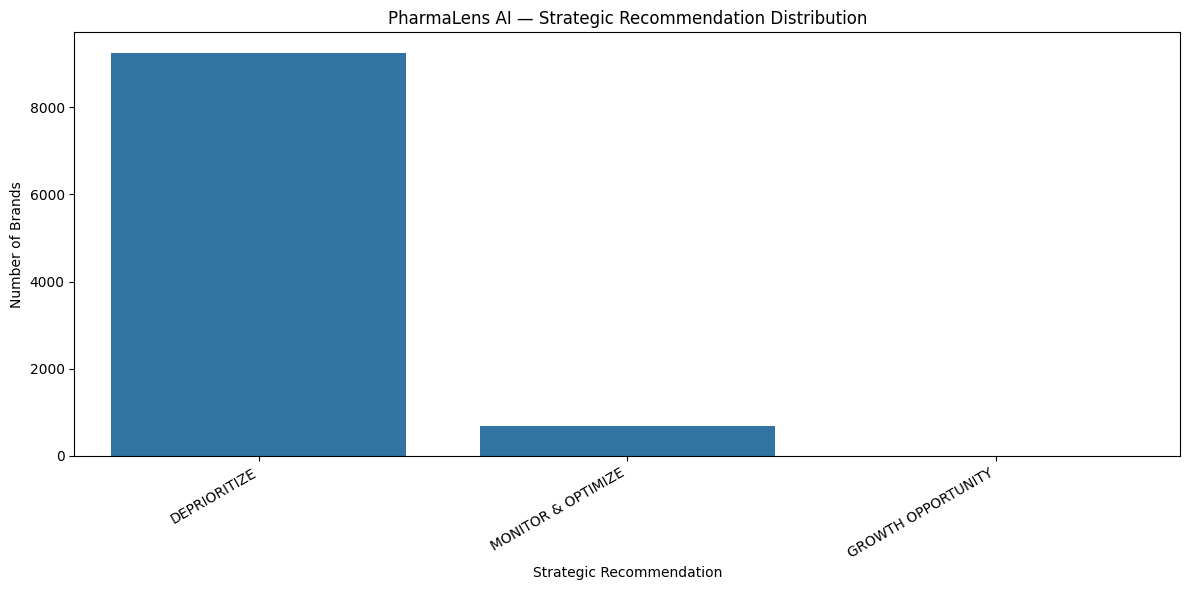

In [30]:
# ============================================================
# 21. RECOMMENDATION DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=recommendation_summary,
    x="Recommendation",
    y="Brand_Count"
)

plt.title(
    "PharmaLens AI — Strategic Recommendation Distribution"
)

plt.xlabel("Strategic Recommendation")
plt.ylabel("Number of Brands")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

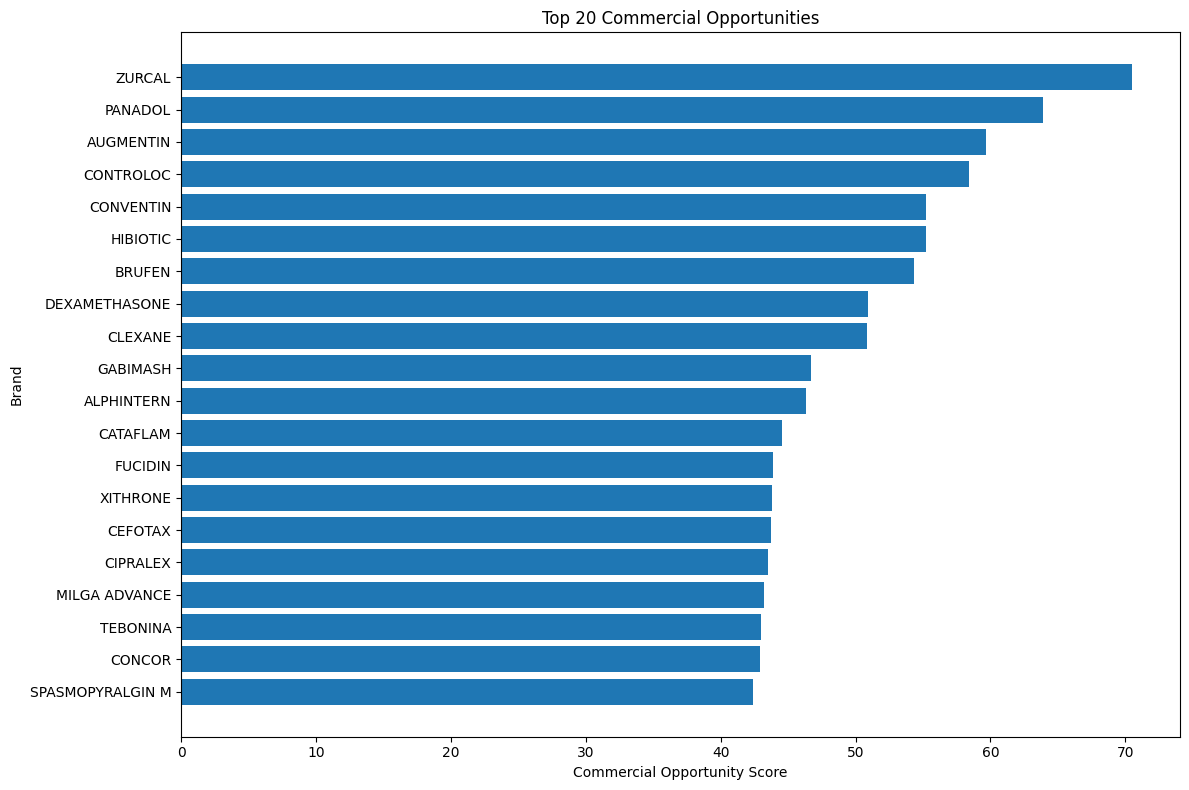

In [31]:
# ============================================================
# 22. TOP COMMERCIAL OPPORTUNITIES
# ============================================================

top_opportunities = (
    brand_recommendations
    .sort_values(
        "Commercial_Opportunity_Score",
        ascending=False
    )
    .head(20)
    .sort_values(
        "Commercial_Opportunity_Score"
    )
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_opportunities["Brand Name"],
    top_opportunities[
        "Commercial_Opportunity_Score"
    ]
)

plt.title(
    "Top 20 Commercial Opportunities"
)

plt.xlabel(
    "Commercial Opportunity Score"
)

plt.ylabel("Brand")

plt.tight_layout()
plt.show()

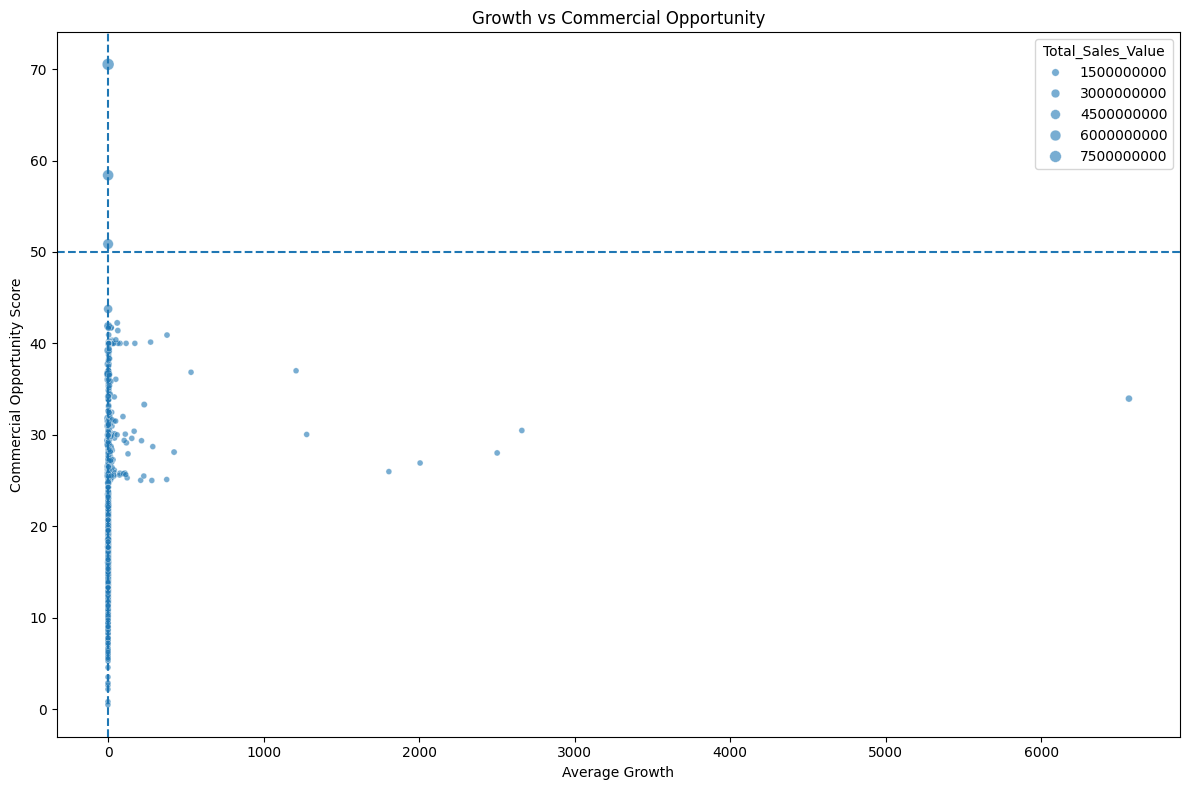

In [32]:
# ============================================================
# 23. GROWTH VS OPPORTUNITY
# ============================================================

plot_data = brand_recommendations.copy()

plot_data["Growth_Display"] = (
    plot_data["Average_Growth"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=plot_data.sample(
        min(1000, len(plot_data)),
        random_state=42
    ),
    x="Growth_Display",
    y="Commercial_Opportunity_Score",
    size="Total_Sales_Value",
    alpha=0.6
)

plt.axhline(
    50,
    linestyle="--"
)

plt.axvline(
    0.05,
    linestyle="--"
)

plt.title(
    "Growth vs Commercial Opportunity"
)

plt.xlabel("Average Growth")
plt.ylabel("Commercial Opportunity Score")

plt.tight_layout()
plt.show()

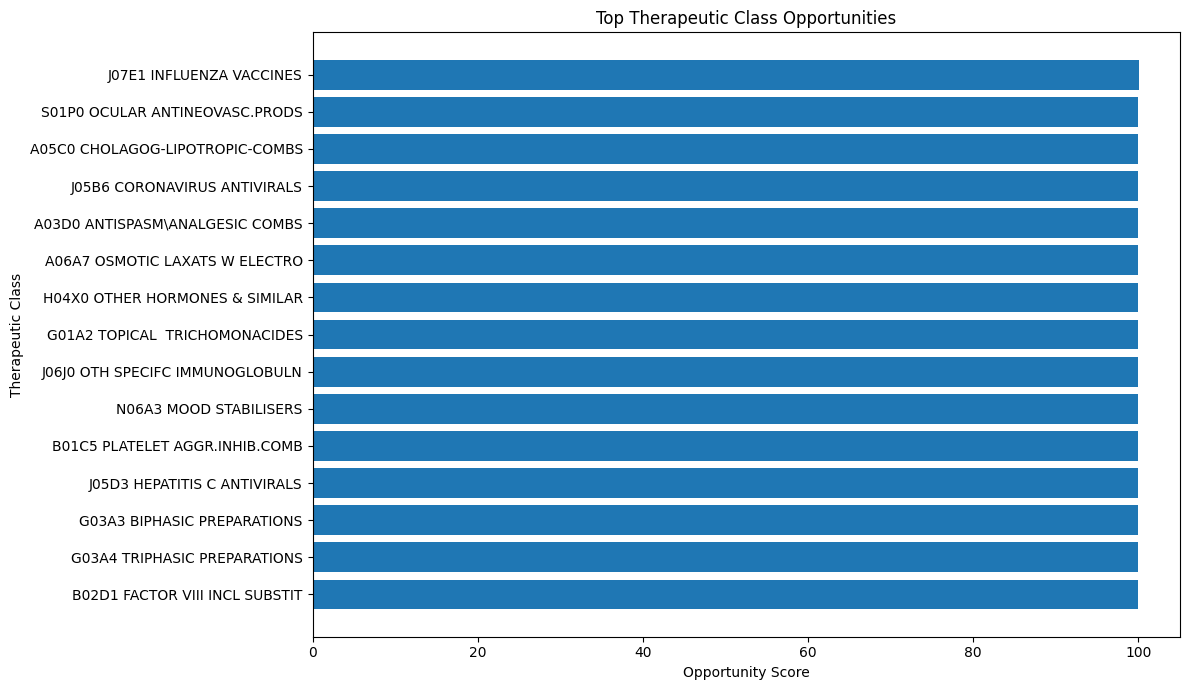

In [33]:
# ============================================================
# 24. TOP THERAPEUTIC OPPORTUNITIES
# ============================================================

top_therapy = (
    therapeutic_opportunities
    .head(15)
    .sort_values("Opportunity_Score")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_therapy["Therapeutic Class"],
    top_therapy["Opportunity_Score"]
)

plt.title(
    "Top Therapeutic Class Opportunities"
)

plt.xlabel("Opportunity Score")
plt.ylabel("Therapeutic Class")

plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# 25. EXECUTIVE RECOMMENDATION DASHBOARD
# ============================================================

total_brands = (
    brand_recommendations["Brand Name"]
    .nunique()
)

invest_count = (
    brand_recommendations[
        brand_recommendations[
            "Strategic_Recommendation"
        ] == "INVEST & ACCELERATE"
    ]["Brand Name"]
    .nunique()
)

defend_count = (
    brand_recommendations[
        brand_recommendations[
            "Strategic_Recommendation"
        ] == "DEFEND & INVEST"
    ]["Brand Name"]
    .nunique()
)

growth_count = (
    brand_recommendations[
        brand_recommendations[
            "Strategic_Recommendation"
        ] == "GROWTH OPPORTUNITY"
    ]["Brand Name"]
    .nunique()
)

monitor_count = (
    brand_recommendations[
        brand_recommendations[
            "Strategic_Recommendation"
        ] == "MONITOR & OPTIMIZE"
    ]["Brand Name"]
    .nunique()
)

deprioritize_count = (
    brand_recommendations[
        brand_recommendations[
            "Strategic_Recommendation"
        ] == "DEPRIORITIZE"
    ]["Brand Name"]
    .nunique()
)

total_market_value = (
    recommendation_df["Sales Value"].sum()
)

print("=" * 70)
print("PHARMALENS AI — RECOMMENDATION EXECUTIVE DASHBOARD")
print("=" * 70)

print(f"\nTotal Brands: {total_brands:,}")

print(
    f"Total Market Value: "
    f"{total_market_value:,.0f}"
)

print(
    f"\nINVEST & ACCELERATE: {invest_count:,}"
)

print(
    f"DEFEND & INVEST: {defend_count:,}"
)

print(
    f"GROWTH OPPORTUNITY: {growth_count:,}"
)

print(
    f"MONITOR & OPTIMIZE: {monitor_count:,}"
)

print(
    f"DEPRIORITIZE: {deprioritize_count:,}"
)

print("=" * 70)

PHARMALENS AI — RECOMMENDATION EXECUTIVE DASHBOARD

Total Brands: 9,958
Total Market Value: 882,881,495,960

INVEST & ACCELERATE: 0
DEFEND & INVEST: 0
GROWTH OPPORTUNITY: 9
MONITOR & OPTIMIZE: 694
DEPRIORITIZE: 9,255


In [46]:
# ============================================================
# 26. EXECUTIVE TOP OPPORTUNITIES


# Ensure metadata exists in brand_recommendations

if "Therapeutic_Class" not in brand_recommendations.columns:

    brand_metadata = (
        df.groupby("Brand Name")
        .agg(
            Therapeutic_Class=("Therapeutic Class", "first"),
            Market_Category=("Market Category", "first")
        )
        .reset_index()
    )

    brand_recommendations = brand_recommendations.merge(
        brand_metadata,
        on="Brand Name",
        how="left"
    )

# ------------------------------------------------------------
# Create Executive Opportunities
# ------------------------------------------------------------

executive_opportunities = (
    brand_recommendations[
        [
            "Brand Name",
            "Manufacturer",
            "Therapeutic_Class",
            "Market_Share",
            "Average_Growth",
            "Commercial_Opportunity_Score",
            "Strategic_Recommendation",
            "Portfolio_Action"
        ]
    ]
    .sort_values(
        "Commercial_Opportunity_Score",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

# Rename for business presentation

executive_opportunities = (
    executive_opportunities.rename(
        columns={
            "Therapeutic_Class": "Therapeutic Class"
        }
    )
)

print("=" * 70)
print("EXECUTIVE TOP 20 OPPORTUNITIES")
print("=" * 70)

executive_opportunities

EXECUTIVE TOP 20 OPPORTUNITIES


,Brand Name,Manufacturer,Therapeutic Class,Market_Share,Average_Growth,Commercial_Opportunity_Score,Strategic_Recommendation,Portfolio_Action
0,ZURCAL,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,0.008839,0.144522,70.522883,GROWTH OPPORTUNITY,Increase promotion and expand distribution
1,PANADOL,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,0.006851,0.132205,63.914717,GROWTH OPPORTUNITY,Increase promotion and expand distribution
2,AUGMENTIN,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,0.007717,0.162927,59.650649,GROWTH OPPORTUNITY,Increase promotion and expand distribution
3,CONTROLOC,ACINO*,A02B2 PROTON PUMP INHIBITORS,0.007205,0.066089,58.395759,GROWTH OPPORTUNITY,Increase promotion and expand distribution
4,CONVENTIN,EVA PHARMA*,N02D0 GABAPENTINOID PRODUCTS,0.005435,0.219972,55.213682,GROWTH OPPORTUNITY,Increase promotion and expand distribution
5,HIBIOTIC,AMOUN PHARM.CO.*,J01C1 BROAD SPECT PENICILL ORAL,0.005769,0.410659,55.191115,GROWTH OPPORTUNITY,Increase promotion and expand distribution
6,BRUFEN,ABBOTT*,M01A1 ANTIRHEUMATICS NON-S PLN,0.005878,0.069674,54.348728,GROWTH OPPORTUNITY,Increase promotion and expand distribution
7,DEXAMETHASONE,MUP/ACDIMA,H02A1 INJ CORTICOSTEROIDS PLAIN,0.001566,3.800153,50.919236,GROWTH OPPORTUNITY,Increase promotion and expand distribution
8,CLEXANE,SANOFI,B01B2 FRACTIONATED HEPARINS,0.006293,0.060350,50.867487,GROWTH OPPORTUNITY,Increase promotion and expand distribution
9,GABIMASH,BIOMED PHARMA.*,N02D0 GABAPENTINOID PRODUCTS,0.006013,0.159022,46.731848,MONITOR & OPTIMIZE,Optimize resources and monitor market performance


In [41]:
# ============================================================
# 27. AUTOMATED AI-STYLE RECOMMENDATION NARRATIVE
# ============================================================

print("\nPHARMALENS AI STRATEGIC RECOMMENDATIONS")
print("=" * 70)

# 1. Investment
if invest_count > 0:
    print(
        f"\n1. INVESTMENT PRIORITY:"
        f"\n   {invest_count} brands show strong commercial "
        f"potential and should receive accelerated investment."
    )

# 2. Defense
if defend_count > 0:
    print(
        f"\n2. MARKET DEFENSE:"
        f"\n   {defend_count} brands should be protected "
        f"through market-share defense and competitive actions."
    )

# 3. Growth
if growth_count > 0:
    print(
        f"\n3. GROWTH OPPORTUNITIES:"
        f"\n   {growth_count} brands represent attractive "
        f"growth opportunities."
    )

# 4. Portfolio optimization
if deprioritize_count > 0:
    print(
        f"\n4. PORTFOLIO OPTIMIZATION:"
        f"\n   {deprioritize_count} brands should be "
        f"reviewed for reduced investment."
    )

print("\n" + "=" * 70)


PHARMALENS AI STRATEGIC RECOMMENDATIONS

3. GROWTH OPPORTUNITIES:
   9 brands represent attractive growth opportunities.

4. PORTFOLIO OPTIMIZATION:
   9255 brands should be reviewed for reduced investment.



In [47]:
# ============================================================
# 28. FINAL RECOMMENDATION TABLE — FINAL
# ============================================================

# Ensure metadata exists in brand_recommendations

if "Therapeutic_Class" not in brand_recommendations.columns:

    brand_metadata = (
        df.groupby("Brand Name")
        .agg(
            Therapeutic_Class=("Therapeutic Class", "first"),
            Market_Category=("Market Category", "first")
        )
        .reset_index()
    )

    brand_recommendations = brand_recommendations.merge(
        brand_metadata,
        on="Brand Name",
        how="left"
    )

# ------------------------------------------------------------
# Create Final Recommendation Table
# ------------------------------------------------------------

final_recommendation = (
    brand_recommendations[
        [
            "Brand Name",
            "Manufacturer",
            "Therapeutic_Class",
            "Market_Category",
            "Total_Sales_Value",
            "Total_Sales_Units",
            "Market_Share",
            "Average_Growth",
            "Latest_Growth",
            "Commercial_Opportunity_Score",
            "Strategic_Recommendation",
            "Portfolio_Action",
            "Priority"
        ]
    ]
    .sort_values(
        [
            "Priority",
            "Commercial_Opportunity_Score"
        ],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Rename columns for final business output
# ------------------------------------------------------------

final_recommendation = (
    final_recommendation.rename(
        columns={
            "Therapeutic_Class": "Therapeutic Class",
            "Market_Category": "Market Category"
        }
    )
)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("=" * 70)
print("FINAL PHARMALENS AI RECOMMENDATION TABLE")
print("=" * 70)

print(
    "Shape:",
    final_recommendation.shape
)

print("\nColumns:")
print(final_recommendation.columns.tolist())

final_recommendation.head(50)

FINAL PHARMALENS AI RECOMMENDATION TABLE
Shape: (9958, 13)

Columns:
['Brand Name', 'Manufacturer', 'Therapeutic Class', 'Market Category', 'Total_Sales_Value', 'Total_Sales_Units', 'Market_Share', 'Average_Growth', 'Latest_Growth', 'Commercial_Opportunity_Score', 'Strategic_Recommendation', 'Portfolio_Action', 'Priority']


,Brand Name,Manufacturer,Therapeutic Class,Market Category,Total_Sales_Value,Total_Sales_Units,Market_Share,Average_Growth,Latest_Growth,Commercial_Opportunity_Score,Strategic_Recommendation,Portfolio_Action,Priority
0,ZURCAL,AUG PHARMA*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,7.804095e+09,9.966563e+07,0.008839,0.144522,-0.029507,70.522883,GROWTH OPPORTUNITY,Increase promotion and expand distribution,3
1,PANADOL,HALEON*,N02B0 NON-NARCOTIC ANALGESICS,ABC ORAL S ORD FILM-COATED TABS,6.048820e+09,1.478063e+08,0.006851,0.132205,0.322500,63.914717,GROWTH OPPORTUNITY,Increase promotion and expand distribution,3
2,AUGMENTIN,GLAXOSMITHKLINE*,J01C1 BROAD SPECT PENICILL ORAL,DGJ ORL L ORD DRY SUSP/SYR/DROPS,6.813283e+09,5.642937e+07,0.007717,0.162927,-0.429715,59.650649,GROWTH OPPORTUNITY,Increase promotion and expand distribution,3
3,CONTROLOC,ACINO*,A02B2 PROTON PUMP INHIBITORS,ABD ORAL S ORD ENTERIC-CTD TABS,6.360948e+09,5.248516e+07,0.007205,0.066089,0.109528,58.395759,GROWTH OPPORTUNITY,Increase promotion and expand distribution,3
4,CONVENTIN,EVA PHARMA*,N02D0 GABAPENTINOID PRODUCTS,ACA ORAL S ORD CAPSULES,4.798667e+09,5.190512e+07,0.005435,0.219972,1.225038,55.213682,GROWTH OPPORTUNITY,Increase promotion and expand distribution,3
5,HIBIOTIC,AMOUN PHARM.CO.*,J01C1 BROAD SPECT PENICILL ORAL,ABC ORAL S ORD FILM-COATED TABS,5.093675e+09,5.724930e+07,0.005769,0.410659,0.457778,55.191115,GROWTH OPPORTUNITY,Increase promotion and expand distribution,3
6,BRUFEN,ABBOTT*,M01A1 ANTIRHEUMATICS NON-S PLN,BBC ORAL S RET FILM-COATED TABS,5.189706e+09,1.234969e+08,0.005878,0.069674,-0.084353,54.348728,GROWTH OPPORTUNITY,Increase promotion and expand distribution,3
7,DEXAMETHASONE,MUP/ACDIMA,H02A1 INJ CORTICOSTEROIDS PLAIN,FMA PARENTERAL ORDINARY AMPOULES,1.383001e+09,3.324874e+07,0.001566,3.800153,3.956651,50.919236,GROWTH OPPORTUNITY,Increase promotion and expand distribution,3
8,CLEXANE,SANOFI,B01B2 FRACTIONATED HEPARINS,FNE P.ORD SC P/FILLED SYRNGS,5.555901e+09,2.716603e+07,0.006293,0.060350,-0.041452,50.867487,GROWTH OPPORTUNITY,Increase promotion and expand distribution,3
9,GABIMASH,BIOMED PHARMA.*,N02D0 GABAPENTINOID PRODUCTS,AAA ORAL S ORD TABLETS,5.308934e+09,3.802812e+07,0.006013,0.159022,-0.851444,46.731848,MONITOR & OPTIMIZE,Optimize resources and monitor market performance,4


In [48]:
# ============================================================
# 29. EXPORT RECOMMENDATION OUTPUTS
# ============================================================

import os

os.makedirs(
    "../outputs",
    exist_ok=True
)

# Main recommendation
final_recommendation.to_csv(
    "../outputs/final_recommendation.csv",
    index=False
)

# Top opportunities
executive_opportunities.to_csv(
    "../outputs/top_recommendation_opportunities.csv",
    index=False
)

# Investment opportunities
investment_recommendations.to_csv(
    "../outputs/investment_recommendations.csv",
    index=False
)

# Growth opportunities
growth_opportunities.to_csv(
    "../outputs/growth_opportunities.csv",
    index=False
)

# Therapeutic opportunities
therapeutic_opportunities.to_csv(
    "../outputs/therapeutic_opportunities.csv",
    index=False
)

# Manufacturer intelligence
manufacturer_intelligence.to_csv(
    "../outputs/manufacturer_recommendations.csv",
    index=False
)

# Channel intelligence
channel_intelligence.to_csv(
    "../outputs/channel_recommendations.csv",
    index=False
)

print("All recommendation outputs exported successfully.")

All recommendation outputs exported successfully.


In [49]:
# ============================================================
# 30. EXECUTIVE RECOMMENDATION WORKBOOK
# ============================================================

excel_path = "../outputs/PharmaLens_AI_Recommendation_Intelligence.xlsx"

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    final_recommendation.to_excel(
        writer,
        sheet_name="Final Recommendations",
        index=False
    )

    executive_opportunities.to_excel(
        writer,
        sheet_name="Top Opportunities",
        index=False
    )

    investment_recommendations.to_excel(
        writer,
        sheet_name="Investment",
        index=False
    )

    growth_opportunities.to_excel(
        writer,
        sheet_name="Growth Opportunities",
        index=False
    )

    therapeutic_opportunities.to_excel(
        writer,
        sheet_name="Therapeutic Opportunities",
        index=False
    )

    manufacturer_intelligence.to_excel(
        writer,
        sheet_name="Manufacturers",
        index=False
    )

    channel_intelligence.to_excel(
        writer,
        sheet_name="Channels",
        index=False
    )

print(
    f"Executive workbook saved to:\n{excel_path}"
)

Executive workbook saved to:
../outputs/PharmaLens_AI_Recommendation_Intelligence.xlsx


In [50]:
# ============================================================
# 31. FINAL QUALITY CHECK
# ============================================================

print("=" * 70)
print("PHARMALENS AI — NOTEBOOK 06 QUALITY CHECK")
print("=" * 70)

print("\nDataset:")
print("Rows:", len(recommendation_df))
print("Brands:", recommendation_df["Brand Name"].nunique())
print("Manufacturers:", recommendation_df["Manufacturer"].nunique())
print(
    "Therapeutic Classes:",
    recommendation_df["Therapeutic Class"].nunique()
)

print("\nRecommendation distribution:")

print(
    brand_recommendations[
        "Strategic_Recommendation"
    ].value_counts()
)

print("\nTop 10 recommended brands:")

print(
    final_recommendation[
        [
            "Brand Name",
            "Manufacturer",
            "Commercial_Opportunity_Score",
            "Strategic_Recommendation"
        ]
    ].head(10)
)

print("\nExports:")
print("✓ final_recommendation.csv")
print("✓ top_recommendation_opportunities.csv")
print("✓ investment_recommendations.csv")
print("✓ growth_opportunities.csv")
print("✓ therapeutic_opportunities.csv")
print("✓ manufacturer_recommendations.csv")
print("✓ channel_recommendations.csv")
print("✓ PharmaLens_AI_Recommendation_Intelligence.xlsx")

print("\n" + "=" * 70)
print("NOTEBOOK 06 — COMPLETED")
print("=" * 70)

PHARMALENS AI — NOTEBOOK 06 QUALITY CHECK

Dataset:
Rows: 909922
Brands: 9958
Manufacturers: 1396
Therapeutic Classes: 513

Recommendation distribution:
Strategic_Recommendation
DEPRIORITIZE          9255
MONITOR & OPTIMIZE     694
GROWTH OPPORTUNITY       9
Name: count, dtype: int64

Top 10 recommended brands:
      Brand Name      Manufacturer  Commercial_Opportunity_Score  \
0         ZURCAL       AUG PHARMA*                     70.522883   
1        PANADOL           HALEON*                     63.914717   
2      AUGMENTIN  GLAXOSMITHKLINE*                     59.650649   
3      CONTROLOC            ACINO*                     58.395759   
4      CONVENTIN       EVA PHARMA*                     55.213682   
5       HIBIOTIC  AMOUN PHARM.CO.*                     55.191115   
6         BRUFEN           ABBOTT*                     54.348728   
7  DEXAMETHASONE        MUP/ACDIMA                     50.919236   
8        CLEXANE            SANOFI                     50.867487   
9      